In [5]:
# Data Analysis: AI-Powered Personalized Recommendations and Consumer Impulse Buying
# Author: Huang Yue
# Date: May 2025

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
sns.set_palette("husl")

print(" Libraries imported successfully!")
print("=" * 60)

 Libraries imported successfully!


In [6]:
# Load Data
print(" Step 1: Load Data")
print("=" * 60)

from google.colab import files
print("Please upload your survey_data.csv file:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename, encoding='utf-8-sig')

print(f"\n Data loaded successfully!")
print(f" Sample size: {len(df)} responses")
print(f" Number of variables: {len(df.columns)} variables")
print("\n" + "=" * 60)

 Step 1: Load Data
Please upload your survey_data.csv file:


Saving survey_data.csv to survey_data.csv

 Data loaded successfully!
 Sample size: 200 responses
 Number of variables: 32 variables



In [7]:
# Data Preview
print("👀 Step 2: Data Preview")
print("=" * 60)

print("\nFirst 5 rows:")
print(df.head())

print("\n\nData information:")
print(df.info())

print("\n\nDescriptive statistics:")
print(df.describe())

print("\n" + "=" * 60)

👀 Step 2: Data Preview

First 5 rows:
   ID  Gender  Age  Occupation  Income  Shopping_Freq  RA1  RA2  RA3  RT1  \
0   1       2    4           5       4              2    5    5    4    5   
1   2       1    2           2       5              2    5    5    5    4   
2   3       1    3           3       1              5    4    3    2    3   
3   4       2    2           1       2              2    5    5    5    5   
4   5       2    3           6       5              2    5    5    5    4   

   ...  PC2  PC3  IB1  IB2  IB3  IB4  IT1  IT2  IT3  IT4  
0  ...    3    5    5    5    5    4    3    2    4    3  
1  ...    3    2    4    5    5    3    4    3    3    3  
2  ...    3    4    4    4    5    3    3    3    2    5  
3  ...    5    4    5    5    5    5    4    5    3    5  
4  ...    4    5    4    4    5    4    5    5    5    5  

[5 rows x 32 columns]


Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 32 columns

In [8]:
# Data Cleaning
print(" Step 3: Data Cleaning")
print("=" * 60)

print("\nMissing values check:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print(" No missing values")
else:
    print(missing[missing > 0])

duplicates = df.duplicated().sum()
print(f"\nDuplicate check: {duplicates} duplicates")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f" Duplicates removed, remaining: {len(df)} responses")

print("\n Data cleaning completed!")
print(f" Final sample size: {len(df)} responses")
print("\n" + "=" * 60)

 Step 3: Data Cleaning

Missing values check:
 No missing values

Duplicate check: 0 duplicates

 Data cleaning completed!
 Final sample size: 200 responses



In [9]:
# Descriptive Statistics - Demographics
print(" Step 4: Descriptive Statistics - Demographics")
print("=" * 60)

gender_map = {1: 'Male', 2: 'Female', 3: 'Other'}
age_map = {1: 'Under 18', 2: '18-25', 3: '26-35', 4: '36-45', 5: '46+'}
occ_map = {1: 'Student', 2: 'Employee', 3: 'Freelancer',
           4: 'Civil Servant', 5: 'Self-employed', 6: 'Other'}
freq_map = {1: 'Almost daily', 2: '2-3 times/week', 3: 'Once/week',
            4: '2-3 times/month', 5: 'Once/month or less'}

print("\nGender Distribution:")
if 'Gender' in df.columns:
    gender_dist = df['Gender'].value_counts()
    for key, value in gender_dist.items():
        label = gender_map.get(key, f'Option {key}')
        pct = value / len(df) * 100
        print(f"  {label}: {value} ({pct:.1f}%)")

print("\nAge Distribution:")
if 'Age' in df.columns:
    age_dist = df['Age'].value_counts().sort_index()
    for key, value in age_dist.items():
        label = age_map.get(key, f'Option {key}')
        pct = value / len(df) * 100
        print(f"  {label}: {value} ({pct:.1f}%)")

print("\nOccupation Distribution:")
if 'Occupation' in df.columns:
    occ_dist = df['Occupation'].value_counts()
    for key, value in occ_dist.items():
        label = occ_map.get(key, f'Option {key}')
        pct = value / len(df) * 100
        print(f"  {label}: {value} ({pct:.1f}%)")

print("\nShopping Frequency:")
if 'Shopping_Freq' in df.columns:
    freq_dist = df['Shopping_Freq'].value_counts().sort_index()
    for key, value in freq_dist.items():
        label = freq_map.get(key, f'Option {key}')
        pct = value / len(df) * 100
        print(f"  {label}: {value} ({pct:.1f}%)")

print("\n" + "=" * 60)

 Step 4: Descriptive Statistics - Demographics

Gender Distribution:
  Female: 106 (53.0%)
  Male: 94 (47.0%)

Age Distribution:
  Under 18: 9 (4.5%)
  18-25: 77 (38.5%)
  26-35: 80 (40.0%)
  36-45: 31 (15.5%)
  46+: 3 (1.5%)

Occupation Distribution:
  Employee: 81 (40.5%)
  Student: 46 (23.0%)
  Freelancer: 27 (13.5%)
  Civil Servant: 18 (9.0%)
  Self-employed: 17 (8.5%)
  Other: 11 (5.5%)

Shopping Frequency:
  Almost daily: 15 (7.5%)
  2-3 times/week: 42 (21.0%)
  Once/week: 48 (24.0%)
  2-3 times/month: 59 (29.5%)
  Once/month or less: 36 (18.0%)



In [10]:
# Calculate Composite Variables
print(" Step 5: Calculate Composite Variables")
print("=" * 60)

variables = {
    'Accuracy': ['RA1', 'RA2', 'RA3'],
    'RealTime': ['RT1', 'RT2', 'RT3'],
    'Emotional': ['EI1', 'EI2', 'EI3'],
    'Personalization': ['PP1', 'PP2', 'PP3'],
    'Resonance': ['ER1', 'ER2', 'ER3'],
    'Privacy': ['PC1', 'PC2', 'PC3'],
    'ImpulseBuy': ['IB1', 'IB2', 'IB3', 'IB4'],
    'ImpulseTrait': ['IT1', 'IT2', 'IT3', 'IT4']
}

for var_name, items in variables.items():
    existing_items = [item for item in items if item in df.columns]
    if existing_items:
        df[var_name] = df[existing_items].mean(axis=1)
        print(f" {var_name}: Calculated")
    else:
        print(f"  {var_name}: Columns not found, skipped")

print("\n Composite variables calculated!")
print("\n" + "=" * 60)

 Step 5: Calculate Composite Variables
 Accuracy: Calculated
 RealTime: Calculated
 Emotional: Calculated
 Personalization: Calculated
 Resonance: Calculated
 Privacy: Calculated
 ImpulseBuy: Calculated
 ImpulseTrait: Calculated

 Composite variables calculated!



In [11]:
# Descriptive Statistics - Core Variables
print(" Step 6: Descriptive Statistics - Core Variables")
print("=" * 60)

core_vars = ['Accuracy', 'RealTime', 'Emotional', 'Personalization',
             'Resonance', 'Privacy', 'ImpulseBuy', 'ImpulseTrait']

existing_vars = [var for var in core_vars if var in df.columns]

if existing_vars:
    desc_stats = df[existing_vars].describe().T
    desc_stats = desc_stats[['mean', 'std', 'min', 'max']]
    desc_stats.columns = ['Mean', 'SD', 'Min', 'Max']

    labels = {
        'Accuracy': 'AI Recommendation Accuracy',
        'RealTime': 'Real-time Responsiveness',
        'Emotional': 'Emotional Interaction',
        'Personalization': 'Perceived Personalization',
        'Resonance': 'Emotional Resonance',
        'Privacy': 'Privacy Concerns',
        'ImpulseBuy': 'Impulse Buying',
        'ImpulseTrait': 'Impulsive Traits'
    }

    desc_stats['Variable'] = desc_stats.index.map(labels)
    desc_stats = desc_stats[['Variable', 'Mean', 'SD', 'Min', 'Max']]

    print("\nDescriptive Statistics of Core Variables:\n")
    print(desc_stats.to_string(index=False))

    desc_stats.to_csv('descriptive_statistics.csv', index=False, encoding='utf-8-sig')
    print("\n Descriptive statistics saved as descriptive_statistics.csv")
else:
    print("  Core variables not found")

print("\n" + "=" * 60)

 Step 6: Descriptive Statistics - Core Variables

Descriptive Statistics of Core Variables:

                  Variable     Mean       SD      Min  Max
AI Recommendation Accuracy 3.856667 0.964188 1.333333  5.0
  Real-time Responsiveness 3.888333 0.838278 1.000000  5.0
     Emotional Interaction 3.446667 0.919690 1.000000  5.0
 Perceived Personalization 3.810000 0.947835 1.333333  5.0
       Emotional Resonance 3.556667 0.998665 1.000000  5.0
          Privacy Concerns 3.668333 0.922150 1.000000  5.0
            Impulse Buying 3.600000 1.017436 1.000000  5.0
          Impulsive Traits 3.350000 0.913673 1.000000  5.0

 Descriptive statistics saved as descriptive_statistics.csv



In [12]:
# Reliability Analysis
print(" Step 7: Reliability Analysis")
print("=" * 60)

def cronbach_alpha(df, items):
    df_items = df[items].dropna()
    item_vars = df_items.var(axis=0, ddof=1)
    total_var = df_items.sum(axis=1).var(ddof=1)
    n_items = len(items)
    alpha = (n_items / (n_items - 1)) * (1 - item_vars.sum() / total_var)
    return alpha

print("\nReliability Test Results:\n")
print(f"{'Construct':<25} {'Items':<8} {'Alpha':<10} {'Level'}")
print("-" * 60)

reliability_results = []

for var_name, items in variables.items():
    existing_items = [item for item in items if item in df.columns]
    if len(existing_items) >= 2:
        alpha = cronbach_alpha(df, existing_items)

        if alpha >= 0.9:
            level = "Excellent"
        elif alpha >= 0.8:
            level = "Good"
        elif alpha >= 0.7:
            level = "Acceptable"
        elif alpha >= 0.6:
            level = "Questionable"
        else:
            level = "Poor"

        reliability_results.append({
            'Construct': var_name,
            'Items': len(existing_items),
            'Alpha': alpha,
            'Level': level
        })

        print(f"{var_name:<25} {len(existing_items):<8} {alpha:<10.3f} {level}")

reliability_df = pd.DataFrame(reliability_results)
reliability_df.to_csv('reliability_analysis.csv', index=False, encoding='utf-8-sig')
print("\n Reliability analysis saved as reliability_analysis.csv")

print("\n" + "=" * 60)

 Step 7: Reliability Analysis

Reliability Test Results:

Construct                 Items    Alpha      Level
------------------------------------------------------------
Accuracy                  3        0.843      Good
RealTime                  3        0.819      Good
Emotional                 3        0.771      Acceptable
Personalization           3        0.836      Good
Resonance                 3        0.844      Good
Privacy                   3        0.784      Acceptable
ImpulseBuy                4        0.884      Good
ImpulseTrait              4        0.799      Acceptable

 Reliability analysis saved as reliability_analysis.csv



 Step 8: Correlation Analysis

Correlation Matrix:

                 Accuracy  RealTime  Emotional  Personalization  Resonance  \
Accuracy            1.000     0.220      0.148            0.190      0.207   
RealTime            0.220     1.000      0.148            0.229      0.238   
Emotional           0.148     0.148      1.000            0.173      0.220   
Personalization     0.190     0.229      0.173            1.000      0.162   
Resonance           0.207     0.238      0.220            0.162      1.000   
Privacy             0.167     0.184      0.193            0.212      0.139   
ImpulseBuy          0.439     0.342      0.328            0.433      0.426   
ImpulseTrait        0.323     0.222      0.321            0.181      0.203   

                 Privacy  ImpulseBuy  ImpulseTrait  
Accuracy           0.167       0.439         0.323  
RealTime           0.184       0.342         0.222  
Emotional          0.193       0.328         0.321  
Personalization    0.212       0.

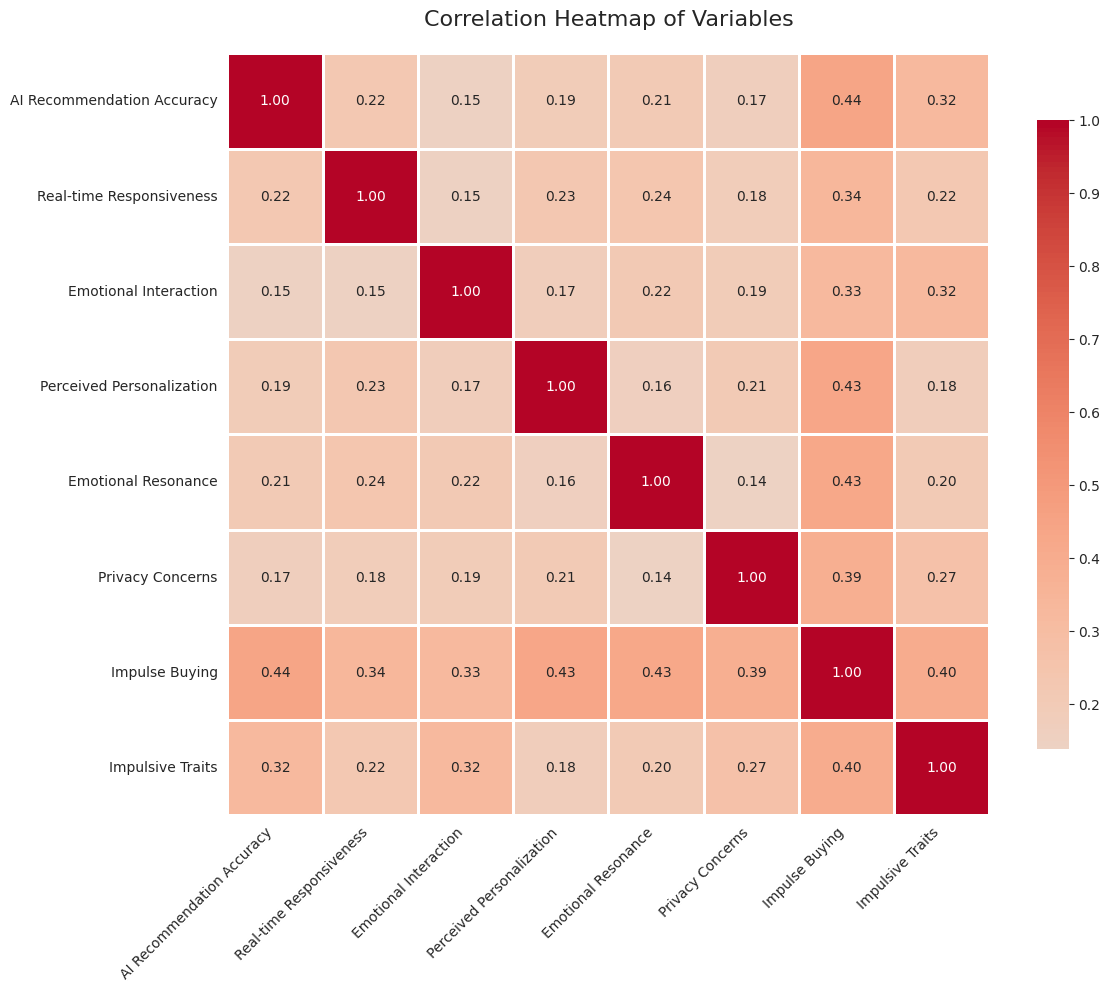


 Correlation heatmap saved as correlation_heatmap.png



In [13]:
# Correlation Analysis
print(" Step 8: Correlation Analysis")
print("=" * 60)

if existing_vars:
    corr_matrix = df[existing_vars].corr()

    print("\nCorrelation Matrix:\n")
    print(corr_matrix.round(3))

    corr_matrix.to_csv('correlation_matrix.csv', encoding='utf-8-sig')
    print("\n Correlation matrix saved as correlation_matrix.csv")

    plt.figure(figsize=(12, 10))

    labels_list = [labels.get(var, var) for var in existing_vars]

    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=1,
                xticklabels=labels_list, yticklabels=labels_list,
                cbar_kws={"shrink": 0.8})

    plt.title('Correlation Heatmap of Variables', fontsize=16, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n Correlation heatmap saved as correlation_heatmap.png")

print("\n" + "=" * 60)

 Step 9: Data Visualization - Variable Distributions


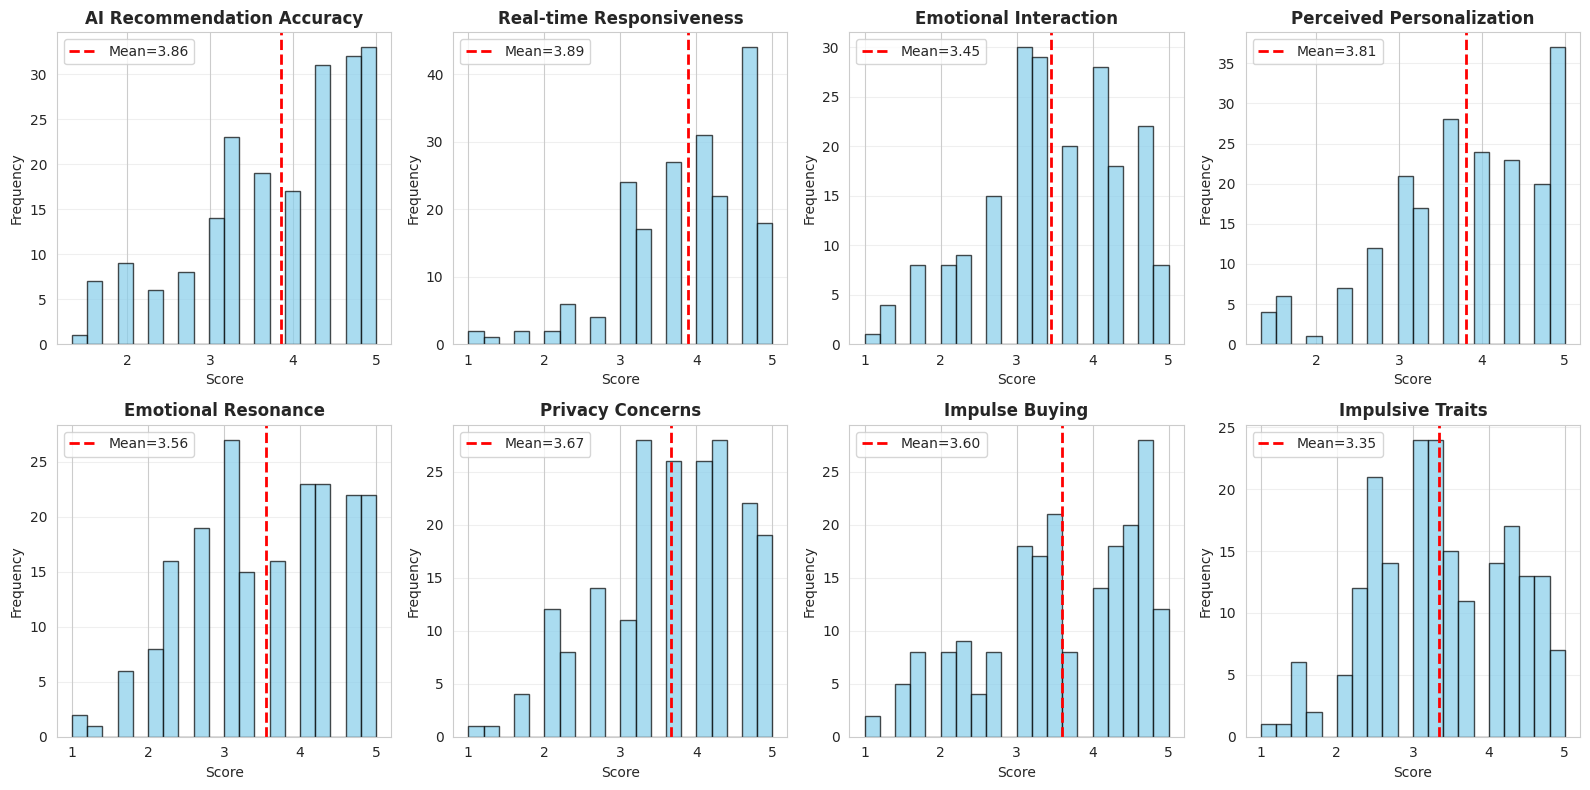


 Variable distribution plots saved



In [14]:
# Variable Distributions
print(" Step 9: Data Visualization - Variable Distributions")
print("=" * 60)

if existing_vars:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for i, var in enumerate(existing_vars):
        if var in df.columns:
            axes[i].hist(df[var].dropna(), bins=20, color='skyblue',
                        edgecolor='black', alpha=0.7)
            axes[i].axvline(df[var].mean(), color='red', linestyle='--',
                           linewidth=2, label=f'Mean={df[var].mean():.2f}')
            axes[i].set_title(labels.get(var, var), fontsize=12, fontweight='bold')
            axes[i].set_xlabel('Score', fontsize=10)
            axes[i].set_ylabel('Frequency', fontsize=10)
            axes[i].legend()
            axes[i].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('variable_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n Variable distribution plots saved")

print("\n" + "=" * 60)

 Step 10: Demographics Visualization


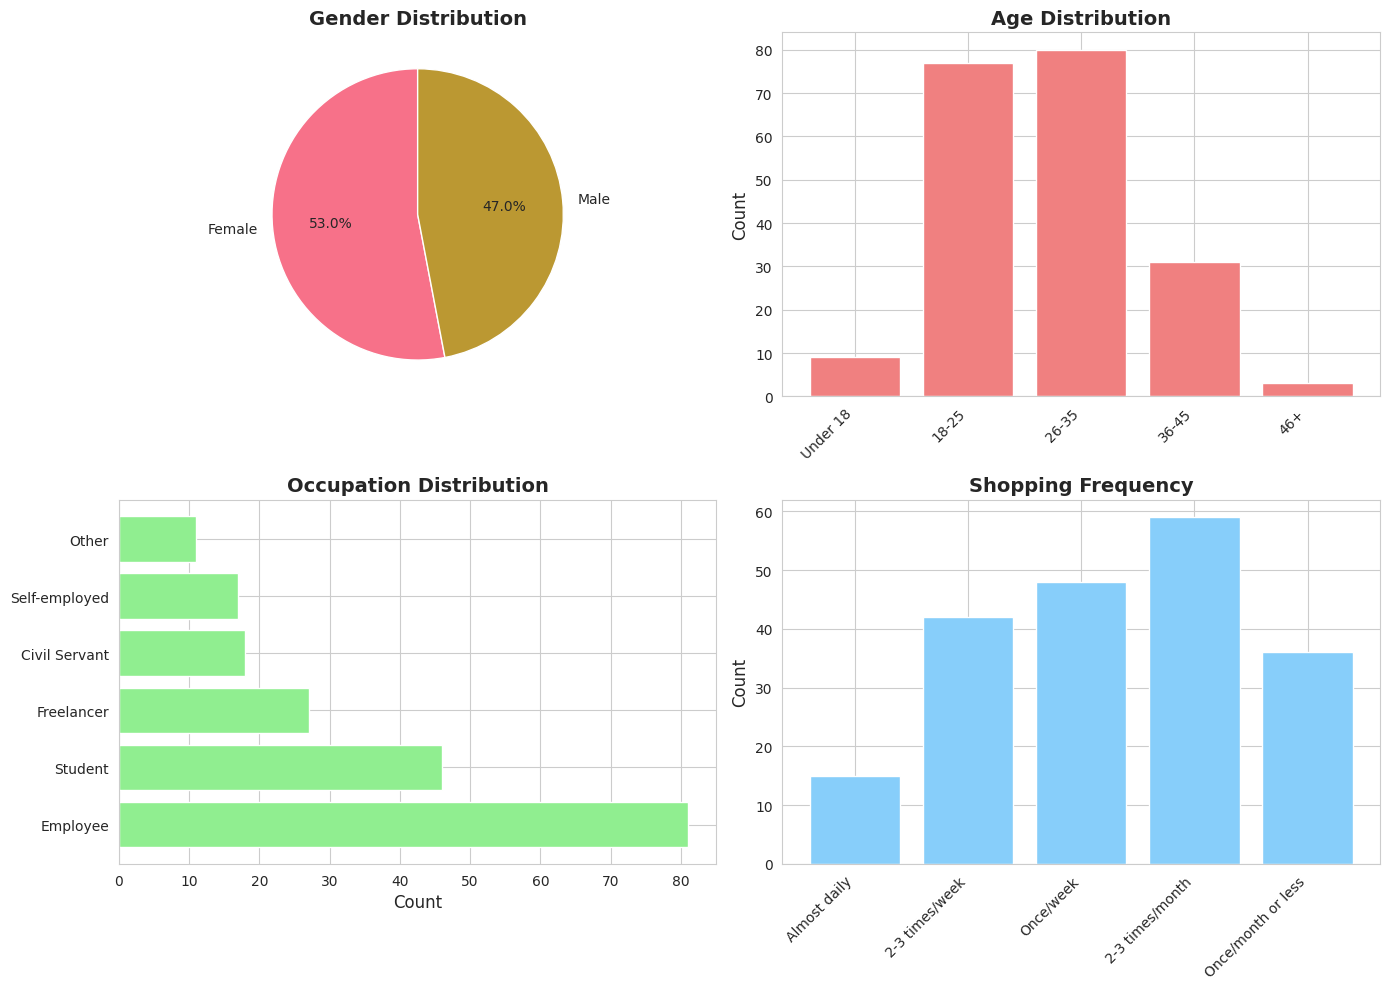


 Demographics plots saved



In [15]:
# Demographics Visualization
print(" Step 10: Demographics Visualization")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

if 'Gender' in df.columns:
    gender_counts = df['Gender'].value_counts()
    gender_labels = [gender_map.get(k, f'Option {k}') for k in gender_counts.index]
    axes[0, 0].pie(gender_counts.values, labels=gender_labels,
                   autopct='%1.1f%%', startangle=90)
    axes[0, 0].set_title('Gender Distribution', fontsize=14, fontweight='bold')

if 'Age' in df.columns:
    age_counts = df['Age'].value_counts().sort_index()
    age_labels = [age_map.get(k, f'Option {k}') for k in age_counts.index]
    axes[0, 1].bar(range(len(age_counts)), age_counts.values, color='lightcoral')
    axes[0, 1].set_xticks(range(len(age_counts)))
    axes[0, 1].set_xticklabels(age_labels, rotation=45, ha='right')
    axes[0, 1].set_title('Age Distribution', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('Count', fontsize=12)

if 'Occupation' in df.columns:
    occ_counts = df['Occupation'].value_counts()
    occ_labels = [occ_map.get(k, f'Option {k}') for k in occ_counts.index]
    axes[1, 0].barh(range(len(occ_counts)), occ_counts.values, color='lightgreen')
    axes[1, 0].set_yticks(range(len(occ_counts)))
    axes[1, 0].set_yticklabels(occ_labels)
    axes[1, 0].set_title('Occupation Distribution', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Count', fontsize=12)

if 'Shopping_Freq' in df.columns:
    freq_counts = df['Shopping_Freq'].value_counts().sort_index()
    freq_labels = [freq_map.get(k, f'Option {k}') for k in freq_counts.index]
    axes[1, 1].bar(range(len(freq_counts)), freq_counts.values, color='lightskyblue')
    axes[1, 1].set_xticks(range(len(freq_counts)))
    axes[1, 1].set_xticklabels(freq_labels, rotation=45, ha='right')
    axes[1, 1].set_title('Shopping Frequency', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.savefig('demographics.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n Demographics plots saved")

print("\n" + "=" * 60)

In [16]:
# Research Readiness Assessment
print(" Step 11: Research Readiness Assessment")
print("=" * 60)

print("\n【Data Quality Assessment】\n")

print(f"1. Sample Size: {len(df)} responses")
if len(df) >= 200:
    print("    Meets minimum requirement for SEM analysis")
elif len(df) >= 150:
    print("     Close to minimum requirement")
else:
    print("    Insufficient sample size")

missing_pct = (df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100
print(f"\n2. Data Completeness: {100-missing_pct:.1f}%")
if missing_pct == 0:
    print("    No missing values")
elif missing_pct < 5:
    print("    Minimal missing values")
else:
    print("     High missing values")

if reliability_results:
    avg_alpha = np.mean([r['Alpha'] for r in reliability_results])
    print(f"\n3. Average Reliability: α = {avg_alpha:.3f}")
    if avg_alpha >= 0.8:
        print("    Excellent reliability")
    elif avg_alpha >= 0.7:
        print("    Good reliability")
    elif avg_alpha >= 0.6:
        print("     Acceptable reliability")
    else:
        print("    Poor reliability")

    low_reliability = [r for r in reliability_results if r['Alpha'] < 0.7]
    if low_reliability:
        print("\n   Dimensions with lower reliability:")
        for r in low_reliability:
            print(f"   - {r['Construct']}: α = {r['Alpha']:.3f}")

print("\n4. Data Distribution:")
if existing_vars:
    for var in existing_vars:
        if var in df.columns:
            skewness = df[var].skew()
            kurtosis = df[var].kurtosis()
            status = " Normal" if abs(skewness) < 1 and abs(kurtosis) < 3 else "⚠️  Skewed"
            print(f"   {labels.get(var, var):<30s}: Skew={skewness:6.2f}, Kurt={kurtosis:6.2f} {status}")

print("\n" + "=" * 60)
print("\n【Overall Assessment】\n")

readiness_score = 0
max_score = 4

if len(df) >= 200:
    readiness_score += 1
if missing_pct < 5:
    readiness_score += 1
if reliability_results and avg_alpha >= 0.7:
    readiness_score += 1
if existing_vars:
    normal_dist = sum([1 for var in existing_vars if var in df.columns and abs(df[var].skew()) < 1])
    if normal_dist / len(existing_vars) > 0.7:
        readiness_score += 1

print(f"Research Readiness Score: {readiness_score}/{max_score}")

if readiness_score == 4:
    print("\n Excellent data quality, fully ready for empirical analysis")
elif readiness_score >= 3:
    print("\n Good data quality, ready for subsequent analysis")
elif readiness_score >= 2:
    print("\n  Fair data quality, suggest adjustments")
else:
    print("\n Poor data quality")

print("\n" + "=" * 60)

 Step 11: Research Readiness Assessment

【Data Quality Assessment】

1. Sample Size: 200 responses
    Meets minimum requirement for SEM analysis

2. Data Completeness: 100.0%
    No missing values

3. Average Reliability: α = 0.822
    Excellent reliability

4. Data Distribution:
   AI Recommendation Accuracy    : Skew= -0.70, Kurt= -0.42  Normal
   Real-time Responsiveness      : Skew= -0.88, Kurt=  0.74  Normal
   Emotional Interaction         : Skew= -0.37, Kurt= -0.43  Normal
   Perceived Personalization     : Skew= -0.60, Kurt= -0.23  Normal
   Emotional Resonance           : Skew= -0.27, Kurt= -0.85  Normal
   Privacy Concerns              : Skew= -0.52, Kurt= -0.42  Normal
   Impulse Buying                : Skew= -0.51, Kurt= -0.68  Normal
   Impulsive Traits              : Skew= -0.07, Kurt= -0.67  Normal


【Overall Assessment】

Research Readiness Score: 4/4

 Excellent data quality, fully ready for empirical analysis



In [17]:
# Generate Summary
print(" Step 12: Generate Analysis Summary")
print("=" * 60)

report = f"""
Data Analysis Summary Report
{'=' * 60}
Author: Huang Yue
Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

1. Sample Characteristics
   - Total sample size: {len(df)} responses
   - Valid responses: {len(df)} responses
   - Data completeness: {100-missing_pct:.1f}%

2. Descriptive Statistics
   Core variables mean range: {df[existing_vars].mean().min():.2f} - {df[existing_vars].mean().max():.2f}
   Standard deviation range: {df[existing_vars].std().min():.2f} - {df[existing_vars].std().max():.2f}

3. Reliability Analysis
   Average Cronbach's Alpha: {avg_alpha:.3f}
   Reliability level: {'Excellent' if avg_alpha >= 0.8 else 'Good' if avg_alpha >= 0.7 else 'Acceptable'}

4. Correlation Analysis
   Strongest positive correlation: {corr_matrix.max().max():.3f}
   Strongest negative correlation: {corr_matrix.min().min():.3f}

5. Research Readiness
   Readiness score: {readiness_score}/{max_score}
   Assessment: {'Excellent' if readiness_score >= 3 else 'Fair'}

{'=' * 60}
Generated Files:
  1. descriptive_statistics.csv
  2. reliability_analysis.csv
  3. correlation_matrix.csv
  4. correlation_heatmap.png
  5. variable_distributions.png
  6. demographics.png
  7. analysis_summary.txt
{'=' * 60}
"""

print(report)

with open('analysis_summary.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("\n Analysis summary saved")
print("\n All analysis completed!")
print("\n" + "=" * 60)

 Step 12: Generate Analysis Summary

Data Analysis Summary Report
Author: Huang Yue
Date: 2026-05-15 18:51:54

1. Sample Characteristics
   - Total sample size: 200 responses
   - Valid responses: 200 responses
   - Data completeness: 100.0%

2. Descriptive Statistics
   Core variables mean range: 3.35 - 3.89
   Standard deviation range: 0.84 - 1.02

3. Reliability Analysis
   Average Cronbach's Alpha: 0.822
   Reliability level: Excellent

4. Correlation Analysis
   Strongest positive correlation: 1.000
   Strongest negative correlation: 0.139

5. Research Readiness
   Readiness score: 4/4
   Assessment: Excellent

Generated Files:
  1. descriptive_statistics.csv
  2. reliability_analysis.csv
  3. correlation_matrix.csv
  4. correlation_heatmap.png
  5. variable_distributions.png
  6. demographics.png
  7. analysis_summary.txt


 Analysis summary saved

 All analysis completed!



In [18]:
# Download all files
print(" Downloading all result files...")
print("=" * 60)

files_to_download = [
    'descriptive_statistics.csv',
    'reliability_analysis.csv',
    'correlation_matrix.csv',
    'correlation_heatmap.png',
    'variable_distributions.png',
    'demographics.png',
    'analysis_summary.txt'
]

for file in files_to_download:
    try:
        files.download(file)
        print(f" Downloaded: {file}")
    except:
        print(f"  Could not download: {file}")

print("\n All files downloaded!")
print("=" * 60)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Downloaded: descriptive_statistics.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

 Downloaded: demographics.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Downloaded: analysis_summary.txt

 All files downloaded!
